# 03 - Neural Network (Improved)

Epoch 1/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 1609.0657 - mae: 38.9540 - val_loss: 1547.0948 - val_mae: 38.1606
Epoch 2/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1403.4417 - mae: 36.1965 - val_loss: 1227.2750 - val_mae: 33.6824
Epoch 3/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 940.6344 - mae: 28.8013 - val_loss: 588.9262 - val_mae: 22.0408
Epoch 4/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 382.5663 - mae: 15.4315 - val_loss: 199.5841 - val_mae: 10.8073
Epoch 5/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 227.0045 - mae: 10.6726 - val_loss: 165.4017 - val_mae: 9.6892
Epoch 6/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 173.9851 - mae: 9.8031 - val_loss: 143.7998 - val_mae: 9.1240
Epoch 7/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 144.1163 - mae: 8.7749 - val_loss: 120.3094 - val_mae: 8.1225
Epoch 8/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 119.7539 - mae: 7.7878 - val_loss: 100.5780 - val_mae: 7.4568
Epoch 9/500

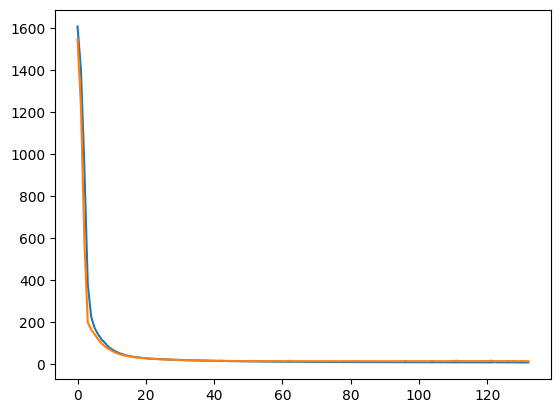

In [1]:
from pathlib import Path
import numpy as np,pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
ROOT=Path.cwd().parent
df=pd.read_csv(ROOT/'data'/'processed'/'master_dataset.csv')
df['date']=pd.to_datetime(df['date'])
df['dayofyear']=df['date'].dt.dayofyear
df['sin_doy']=np.sin(2*np.pi*df['dayofyear']/365.25)
df['cos_doy']=np.cos(2*np.pi*df['dayofyear']/365.25)
features=['ssn','kp_mean','ap_daily','f107_obs','dst_daily_mean','sin_doy','cos_doy']
data=df[features+['daily_mean_tec']].dropna()
X=data[features].values
y=data['daily_mean_tec'].values
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
sc=StandardScaler();Xtr=sc.fit_transform(Xtr);Xte=sc.transform(Xte)
model=Sequential([Dense(64,activation='relu'),Dense(32,activation='relu'),Dense(16,activation='relu'),Dense(8,activation='relu'),Dense(1)])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
hist=model.fit(Xtr,ytr,validation_split=0.2,epochs=500,batch_size=32,callbacks=[EarlyStopping(monitor='val_loss',patience=30,restore_best_weights=True)],verbose=1)
pred=model.predict(Xte).flatten()
print('MAE',mean_absolute_error(yte,pred))
print('RMSE',np.sqrt(mean_squared_error(yte,pred)))
print('R2',r2_score(yte,pred))
plt.plot(hist.history['loss']);plt.plot(hist.history['val_loss']);plt.show()

  Metric     Value
0    MAE  3.188577
1   RMSE  4.364438
2     R2  0.810658


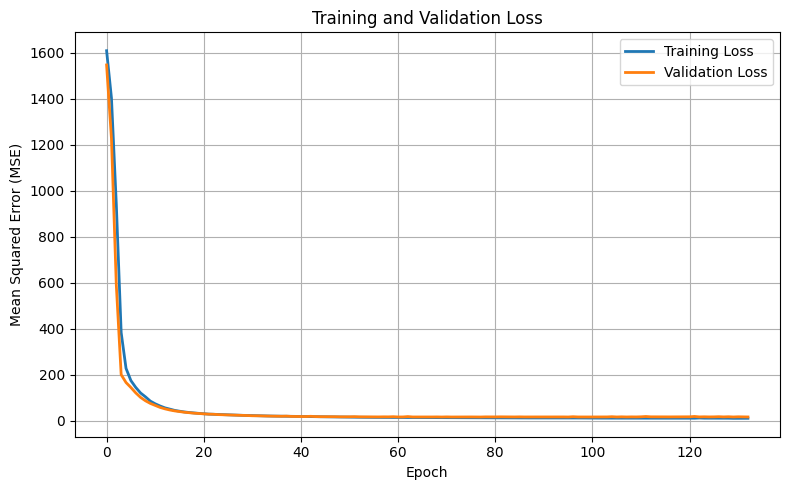

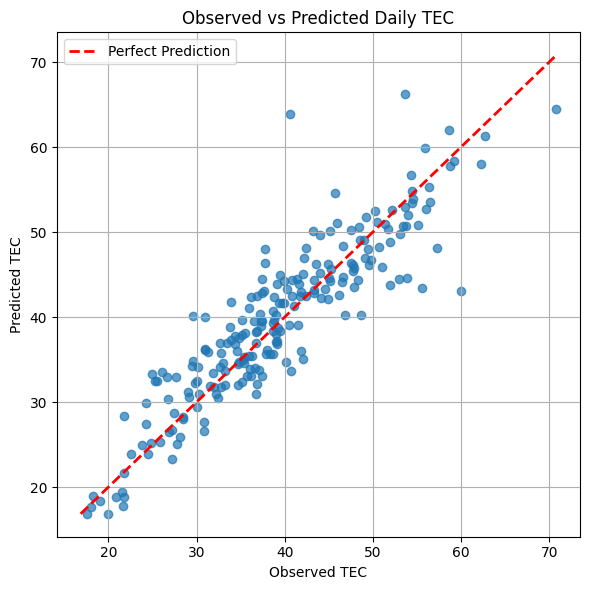


Saved to:
C:\Users\user\Documents\Data Science\busola\TEC_Project\results
  • neural_network_metrics.csv
  • training_validation_loss.png
  • observed_vs_predicted.png


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =====================================
# Create output folder
# =====================================

ROOT = Path.cwd().parent
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# =====================================
# Metrics
# =====================================

mae = mean_absolute_error(yte, pred)
rmse = np.sqrt(mean_squared_error(yte, pred))
r2 = r2_score(yte, pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

metrics.to_csv(
    RESULTS_DIR / "neural_network_metrics.csv",
    index=False
)

print(metrics)

# =====================================
# Training / Validation Loss
# =====================================

plt.figure(figsize=(8,5))

plt.plot(
    hist.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    hist.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =====================================
# Observed vs Predicted
# =====================================

plt.figure(figsize=(6,6))

plt.scatter(
    yte,
    pred,
    alpha=0.7
)

minimum = min(yte.min(), pred.min())
maximum = max(yte.max(), pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Observed TEC")
plt.ylabel("Predicted TEC")
plt.title("Observed vs Predicted Daily TEC")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "observed_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print()
print("Saved to:")
print(RESULTS_DIR)
print("  • neural_network_metrics.csv")
print("  • training_validation_loss.png")
print("  • observed_vs_predicted.png")